# City Creation
This notebook created and visualises the different cities which will be used in the simulations.

In [2]:
%load_ext autoreload
%autoreload 2

In [18]:
from utils.city_metrics import CityCreation

# Creating the grid city 
All the graphs are based off an initial 6x8 grid layout which has the same start and exit positions. Each city then has edges removed to make the layout more bottlenecked.

In [13]:
import networkx as nx
import copy 

In [5]:
G = nx.grid_2d_graph(6, 9)
mapping = {(col, row): f"T{row * 6 + col}" for col, row in G.nodes()}

# Adding exits
mapping[(0, 8)] = 'E1'
mapping[(5, 8)] = 'E2'
mapping[(0, 0)] = 'E3'
mapping[(5, 0)] = 'E4'

# Adding starts
mapping[(3, 6)] = 'S1'
mapping[(4, 5)] = 'S2'
mapping[(1, 5)] = 'S3'
mapping[(2, 2)] = 'S4'

pos = {mapping[(x, y)]: (x, y) for x, y in G.nodes()}
G = nx.relabel_nodes(G, mapping)

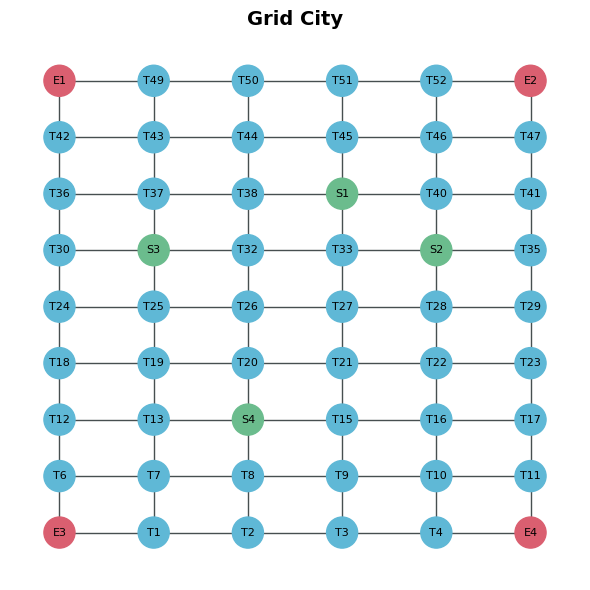

Avg Path Length     → 6.5
Max Betweeness      → 0.169
Articulation Points → 0 ([])
Edge Density        → 0.065
Critical Edge       → ('T27', 'T33') (0.109)


In [27]:
grid = CityCreation(
    G=G, city_name='Grid City'
)
grid_metrics = grid.calculate_city_metrics()
grid.plot_city(
    save=False, pos=pos
)
grid.save_graph_pickle()

## Creating the moderate city
This city will remove some edges to create bottle neck areas.

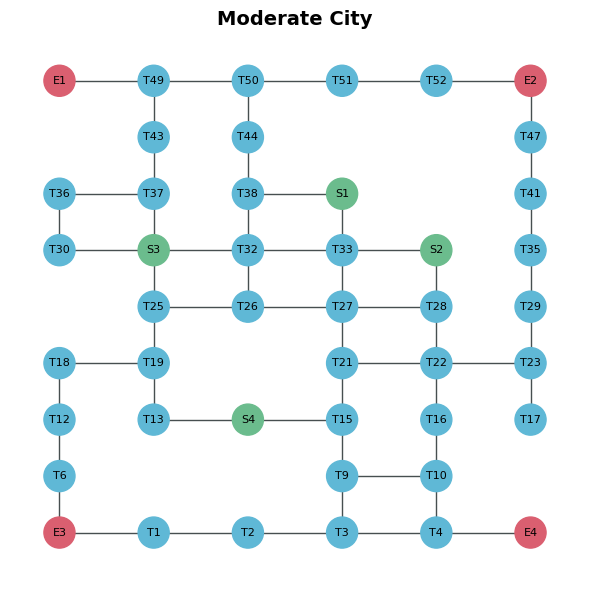

Avg Path Length     → 7.0
Max Betweeness      → 0.281
Articulation Points → 3 (['T4', 'T23', 'T49'])
Edge Density        → 0.0566
Critical Edge       → ('T22', 'T23') (0.207)


In [28]:
G_moderate = copy.deepcopy(G)
pos_moderate = copy.deepcopy(pos)

moderate_nodes_to_remove = [
    "T42", "T24",
    "T7",
    "T20", "T8",
    "T45",
    "T46", "T40",
    "T11"
]
G_moderate.remove_nodes_from(moderate_nodes_to_remove)
for node in moderate_nodes_to_remove:
    pos_moderate.pop(node)

G_moderate.remove_edges_from([
    ('T43', 'T44'), ('T37', 'T38'), ('T12', 'T13'),
    ('T16', 'T17'), ('T15', 'T16'),
    ('S2', 'T35'), ('T28', 'T29')
])


moderate = CityCreation(
    G=G_moderate, city_name='Moderate City'
)
moderate_metrics = moderate.calculate_city_metrics()
moderate.plot_city(
    save=False, pos=pos_moderate
)
moderate.save_graph_pickle()

## Bottlenecked City
This city should have key nodes which are essential for an agent to go from a start node to an exit node.

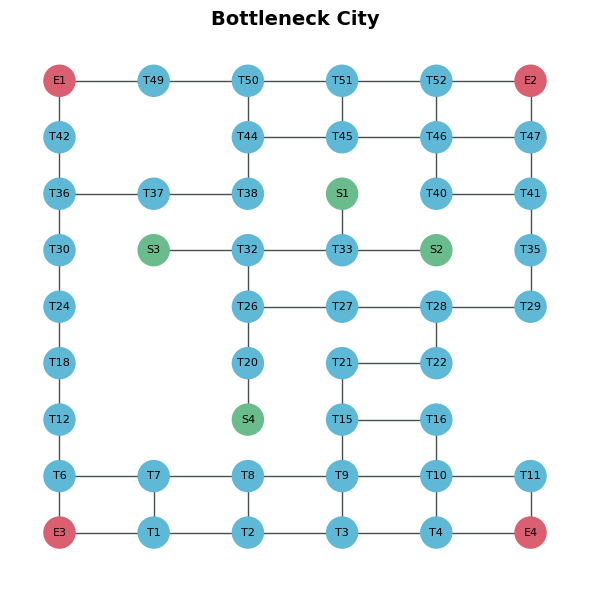

Avg Path Length     → 12.0
Max Betweeness      → 0.477
Articulation Points → 6 (['T20', 'T26', 'T32', 'T33', 'T27', 'T28'])
Edge Density        → 0.0523
Critical Edge       → ('T22', 'T28') (0.326)


In [29]:
G_bottleneck = copy.deepcopy(G)
pos_bottleneck = copy.deepcopy(pos)

bottleneck_nodes_to_remove = [
    "T23",
    "T25", "T19", "T13", "T17", "T43"
]
G_bottleneck.remove_nodes_from(bottleneck_nodes_to_remove)
for node in bottleneck_nodes_to_remove:
    pos_bottleneck.pop(node)

G_bottleneck.remove_edges_from([
    # START NODES
    ("S1", "T45"), ("S1", "T38"), ("S1", "T40"),
    ("S2", "T40"), ("S2", "T35"), ("S2", "T28"),
    ("S3", "T37"), ("S3", "T30"), ("S3", "T25"),
    ("S4", "T13"), ("S4", "T8"), ("S4", "T15"),
    # SURROUNDING BOTTLENECK NODES
    ("T32", "T38"), ("T25", "T26"), ("T20", "T19"),
    ("T20", "T21"), ("T27", "T21"), ("T33", "T27"),
    ("T22", "T16")
])

bottleneck = CityCreation(
    G=G_bottleneck, city_name='Bottleneck City'
)
bottleneck_metrics = bottleneck.calculate_city_metrics()
bottleneck.plot_city(
    save=False, pos=pos_bottleneck
)
bottleneck.save_graph_pickle()

## Metrics
How can I now confirm other than visually that these cities represent different situations?

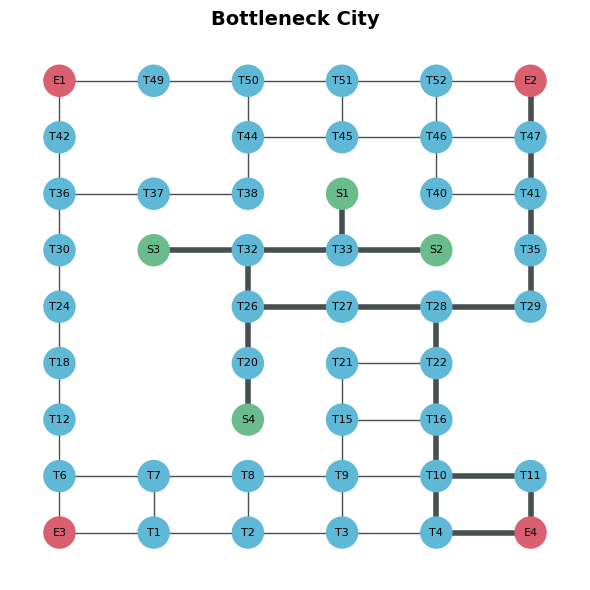

Avg Path Length     → 11.5
Max Betweeness      → 0.49
Articulation Points → 6 (['T20', 'T26', 'T32', 'T33', 'T27', 'T28'])
Edge Density        → 0.0532
Critical Edge       → ('T22', 'T28') (0.34)


In [26]:
G_bottleneck = copy.deepcopy(G)
pos_bottleneck = copy.deepcopy(pos)

bottleneck_nodes_to_remove = [
    "T23",
    "T25", "T19", "T13", "T17", "T43"
]
G_bottleneck.remove_nodes_from(bottleneck_nodes_to_remove)
for node in bottleneck_nodes_to_remove:
    pos_bottleneck.pop(node)

G_bottleneck.remove_edges_from([
    # START NODES
    ("S1", "T45"), ("S1", "T38"), ("S1", "T40"),
    ("S2", "T40"), ("S2", "T35"), ("S2", "T28"),
    ("S3", "T37"), ("S3", "T30"), ("S3", "T25"),
    ("S4", "T13"), ("S4", "T8"), ("S4", "T15"),
    # SURROUNDING BOTTLENECK NODES
    ("T32", "T38"), ("T25", "T26"), ("T20", "T19"),
    ("T20", "T21"), ("T27", "T21"), ("T33", "T27"),
    # ("T22", "T16")
])

bottleneck = CityCreation(
    G=G_bottleneck, city_name='Bottleneck City'
)
bottleneck_metrics = bottleneck.calculate_city_metrics()

bottleneck.plot_city(
    save=False, pos=pos_bottleneck, show_paths=True
)